## Data Mining w praktyce: przewidywanie zachowań klientów AdventureWorks z użyciem Pythona
### Mikołaj Kubś 272662

Data Mining (eksploracja danych / knowledge discovery in databases - KDD) polega na znalezieniu nieoczywistych wzorców, trendów i zależności istniejących w dużym zbiorze danych. 

Może albo pomóc opisać zbiór danych, albo przewidzieć rezultat na podstawie algorytmów uczenia maszynowego czy nawet sztucznej inteligencji.

Firmy wykorzystują te relacje do podejmowania mądrzejszych decyzji – od prognozowania sprzedaży po dogłębne zrozumienie zachowań klientów.

## Zyski i wyzwania

### Zyski

- Data mining bierze surowe dane i znajduje w nich pewien porządek. To może pomóc podejmować decyzje w wielu różnych korporacyjnych i przemysłowych działach, jak reklamowanie/marketing, finanse, sektor publiczny, sektor zdrowotny, HR, manufakturowanie, sprzedaż czy zarządzanie łańcuchem dostaw (SCM)

- Oszczędności: dzięki analizie danych o wydajności z wielu źródeł, można zidentyfikować problemy w procesach biznesowych. Dzięki takiej identyfikacji łatwiej będzie się ich pozbyć i zwiększyć wydajność i szybkość takich procesów.

- Data mining to wszechstronne narzędzie - każdy dział, który zbiera i analizuje dane, może z niego skorzystać.

### Wyzwania

- Złożoność - data mining wymaga wiedzy z wielu działów IT - data engineering, data analysis i machine learning. Przyda się solidna wiedza z Pythona/R i SQLa. Bez dobrej znajomości machine learningu czy popełnienia błędów na poprzednich krokach, łatwo wytworzyć analizy oparte na kompletnie nieprawdziwych danych. Trzeba też uważać na nieujawnianie danych osobowych.

- Wymóg szerokiego i szczegółowego zbioru danych - trudne, zwłaszcza w dużych, starszych firmach, gdzie dane mogą być nieuporządkowane i niskiej jakości. Data mining wymaga czystego i dużego zbioru danych - najlepiej na podstawie Data Warehouse, którego zbudowanie będzie trudne, zwłaszcza z różnymi data pipelines łączące bardzo różne źródła danych.

- Niepewność - nawet dobrze przeprowadzona próba data mining może nie przynieść żadnych wartościowych rezultatów. Gorzej, jeśli zwróci rezultaty niezgodne z prawdą na podstawie różnych błędów w tym skomplikowanym procesie. Trzeba też pamiętać, że korelacja nie oznacza związku przyczynowego. Dobra, krytyczna analiza jest tu, jak zawsze, ważna. 


## Analiza w praktyce

Zajmiejmy się praktycznym przykładem Data mining dla dobrze znanego nam zbioru danych - AdventureWorks, a dokładniej jego Data Warehouse odpowiednika - AdventureWorksDW2014. Wybrałem wersję Data Warehouse, bo przechowuje czyste i zagregowane dane, np. view o nazwie dbo.vTargetMail

## Przedmiot analizy

Postaramy się dowiedzieć, co sprawia, że dany klient kupi rower?

## Zastosowana technika

Aby dojść do odpowiedzi, skorzystamy z potężnego i intuicyjnego algorytmu klasyfikacyjnego - Decision Tree / Drzewe Decyzyjne. Decision Tree działa jak schemat blokowy, zadając serię pytań, aby dojść do ostatecznej decyzji. Wynik mozna też łatwo zwizualizować i zrozumieć.

## Nowoczesne narzędzia

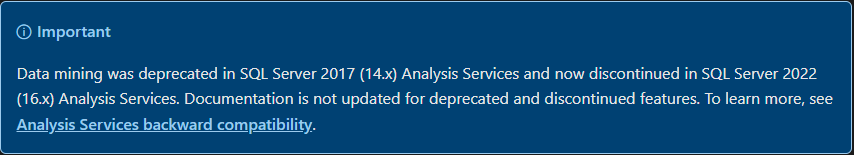

Niestety jak widać, należy używać starszej wersji SQL Server Analysis Services, aby wykonać data mining właśnie w Analysis Services. Dlatego skorzystałem z nowoczesnego narzędzia jakim jest Python, szeroko używanym do Machine Learningu i data engineering dzięki jego prostocie i bogactwie bibliotek. Innym językiem programowania często używanym w data science jest R. Przyda się też wiedza z SQL, którego używa się na każdym kroku w prawie każdej firmie zbierającej i analizującej swoje dane.

## Krok 1: Ładowanie danych z hurtowni danych

Pierwszym krokiem w każdym projekcie analitycznym jest pozyskanie danych. Łączymy się bezpośrednio z naszą bazą danych AdventureWorksDW na SQL Server i za pomocą zapytania SQL pobieramy potrzebne dane z widoku vTargetMail. Ten widok w wygodny sposób łączy już informacje o klientach i ich historii zakupowej.
Używamy biblioteki pandas, aby załadować te dane wprost do obiektu DataFrame, która jest w zasadzie inteligentną, potężną tabelą, na której możemy operować w Pythonie.

In [10]:
from typing import LiteralString
import pandas as pd
import pyodbc

SERVER_NAME = 'DESKTOP-2GLE46P'
DATABASE_NAME = 'AdventureWorksDW2014'

# używa Windows Authentication (Trusted_Connection=yes)
connection_string: LiteralString = f'DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={SERVER_NAME};DATABASE={DATABASE_NAME};Trusted_Connection=yes;'

sql_query = """
SELECT
    [CustomerKey],
    [Age],
    [MaritalStatus],
    [Gender],
    [YearlyIncome],
    [TotalChildren],
    [NumberChildrenAtHome],
    [EnglishEducation],
    [EnglishOccupation],
    [HouseOwnerFlag],
    [NumberCarsOwned],
    [CommuteDistance],
    [Region],
    [BikeBuyer]
FROM
    dbo.vTargetMail
"""

odbc_connection: pyodbc.Connection = pyodbc.connect(connection_string)

pd.set_option('display.max_columns', None)

df: pd.DataFrame = pd.read_sql(sql_query, odbc_connection)

odbc_connection.close()

print(df.head())

C:\Users\Jantar\AppData\Local\Temp\ipykernel_5420\1560895604.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df: pd.DataFrame = pd.read_sql(sql_query, odbc_connection)


   CustomerKey  Age MaritalStatus Gender  YearlyIncome  TotalChildren  \
0        11000   53             M      M       90000.0              2   
1        11001   49             S      M       60000.0              3   
2        11002   54             M      M       60000.0              3   
3        11003   51             S      F       70000.0              0   
4        11004   45             S      F       80000.0              5   

   NumberChildrenAtHome EnglishEducation EnglishOccupation HouseOwnerFlag  \
0                     0        Bachelors      Professional              1   
1                     3        Bachelors      Professional              0   
2                     3        Bachelors      Professional              1   
3                     0        Bachelors      Professional              0   
4                     5        Bachelors      Professional              1   

   NumberCarsOwned CommuteDistance   Region  BikeBuyer  
0                0       1-2 Miles  Pacif

## Krok 2: Przygotowanie danych do analizy

Następnie należy dokonać preprocessingu danych. 

Musimy przekonwertować string (np. MaritalStatus) na jakąś liczbową wartość. Można by każdej wartości string dla kolumny z kategoriami przypisać inną liczbę. Ale lepiej dla algorytmu maszynowego będzie stworzyć dla każdej kategorii osobną kolumnę i przypisać wartość 1/0 (tak/nie). Na przykład, dla EnglishEducation, mamy kategorie jak "Graduate Degree", "High School", "Partial College" itd. Dla każdej wartości tworzymy osobną kolumnę i tylko w (maksymalnie) jednej przypiszemy wartość 1.  
Można to łatwo osiągnąć dzięki funkcji pandas.get_dummies, która dla określonych kolumn wykona ten algorytm. Dla modeli liniowych (linear/logistic regression) należy ustawić parametr drop_first na True, aby usunąć liniową zależność. Na przykład mamy kolumnę kolor, która ma wartość red, blue lub green. Jedna kolumna jest nadmiarowa, ponieważ jeśli zarówno blue jak i green są nieprawdziwe, to wiadomo, że red jest prawdziwy. Modele liniowe matematycznie zakładają, że kolumny są niezależne od siebie, więc taka zależność musi być usunięta.

Kolejnym krokiem jest usunięcie danych, których model nie powinien wykorzystywać do nauki. CustomerKey jest niepotrzebny - nie chcemy, żeby model uczył się zależności dla konkretnych klientów, więc trzeba tą kolumnę usunąć.

In [11]:
df_processed: pd.DataFrame = df.copy()

df_processed = df_processed.drop('CustomerKey', axis=1)

df_processed = pd.get_dummies(df_processed, columns=[
    'MaritalStatus', 'Gender', 'EnglishEducation', 
    'EnglishOccupation', 'CommuteDistance', 'Region'
], drop_first=True)

print("\nPrzykładowy, pierwszy wiersz:")
print(df_processed.head())
print("\nKolumny dostępne do modelowania:")
print(df_processed.columns)


Przykładowy, pierwszy wiersz:
   Age  YearlyIncome  TotalChildren  NumberChildrenAtHome HouseOwnerFlag  \
0   53       90000.0              2                     0              1   
1   49       60000.0              3                     3              0   
2   54       60000.0              3                     3              1   
3   51       70000.0              0                     0              0   
4   45       80000.0              5                     5              1   

   NumberCarsOwned  BikeBuyer  MaritalStatus_S  Gender_M  \
0                0          1            False      True   
1                1          1             True      True   
2                1          1            False      True   
3                1          1             True     False   
4                4          1             True     False   

   EnglishEducation_Graduate Degree  EnglishEducation_High School  \
0                             False                         False   
1            

## Krok 3: trenowanie modelu

Jak dobrze wiemy z kursu Sztuczna Inteligencja i MSID, dane zwyczajowo dzielimy na zbiór X i Y, gdzie X zawiera wszystkie dane (features) których model będzie używał do przewidzenia wartości w kolumnie Y. 

Bogate w funkcje biblioteki Pythona jak sklearn pomogą łatwo podzielić dane na zbiór testowy (20%) i treningowy (reszta - 80%). Oczywiście nie można testować modelu na danych w zbiorze testowym, bo chcemy sprawdzić, czy zgeneralizował swoją wiedzę na tyle, by być użytecznym.

Sklearn zawiera już DecisionTreeClassifier - klasyfikator, którego użyjemy. Dzięki max_depth=4 będzie można jasno zwizualizować nasze dane. Ustawienie random_state na dowolną, stałą liczbę sprawi, że zawsze będziemy mieć ten sam wynik dla tych samych danych. 

Następnie trenujemy model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

X: pd.DataFrame = df_processed.drop('BikeBuyer', axis=1)
Y = df_processed['BikeBuyer']             

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=4, random_state=42)

model.fit(X_train, Y_train)

print("\nDecisionTree model wytrenowany")


DecisionTree model wytrenowany


## Ocena wydajności modelu

Sklearn oferuje gotową implementację różnych klasycznych metryk jak precission, recall czy f1-score. Wartość support oznacza, ile mamy przykładów dla danych klas. Tutaj złożyło się tak, że jest po prawie równo klientów co kupili rower i co go nie kupili.

Accuracy to procent poprawnie odgadniętych klas. W tym wypadku jest to tylko 65% - relatywnie niska wartość, ale zawsze lepiej niż 50%. Model definitywnie się czegoś nauczył, natomiast prawdopodobnie zachowania klientów są inherentnie nieprzewidywalne lub model został słabo wytrenowany - zły model, za mała liczba danych, złe parametry, zła jakość danych (raczej nie). Zajmujemy się też fikcyjnym zbiorem danych - Adventure Works został spreparowany przez Microsoft, więc może w nim brakować dokładnego odwzorowania rzeczywistości.

W Classification Report widzimy podobne wartości dla precision, recall i f1-score. Wyniki są słabsze dla BikeBuyer = 1, zwłaszcza recall.

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

accuracy = accuracy_score(Y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.2f}")

print("\nClassification Report:")
print(classification_report(Y_test, y_pred))


Model Accuracy: 0.65

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.69      0.66      1884
           1       0.65      0.60      0.62      1813

    accuracy                           0.65      3697
   macro avg       0.65      0.64      0.64      3697
weighted avg       0.65      0.65      0.64      3697



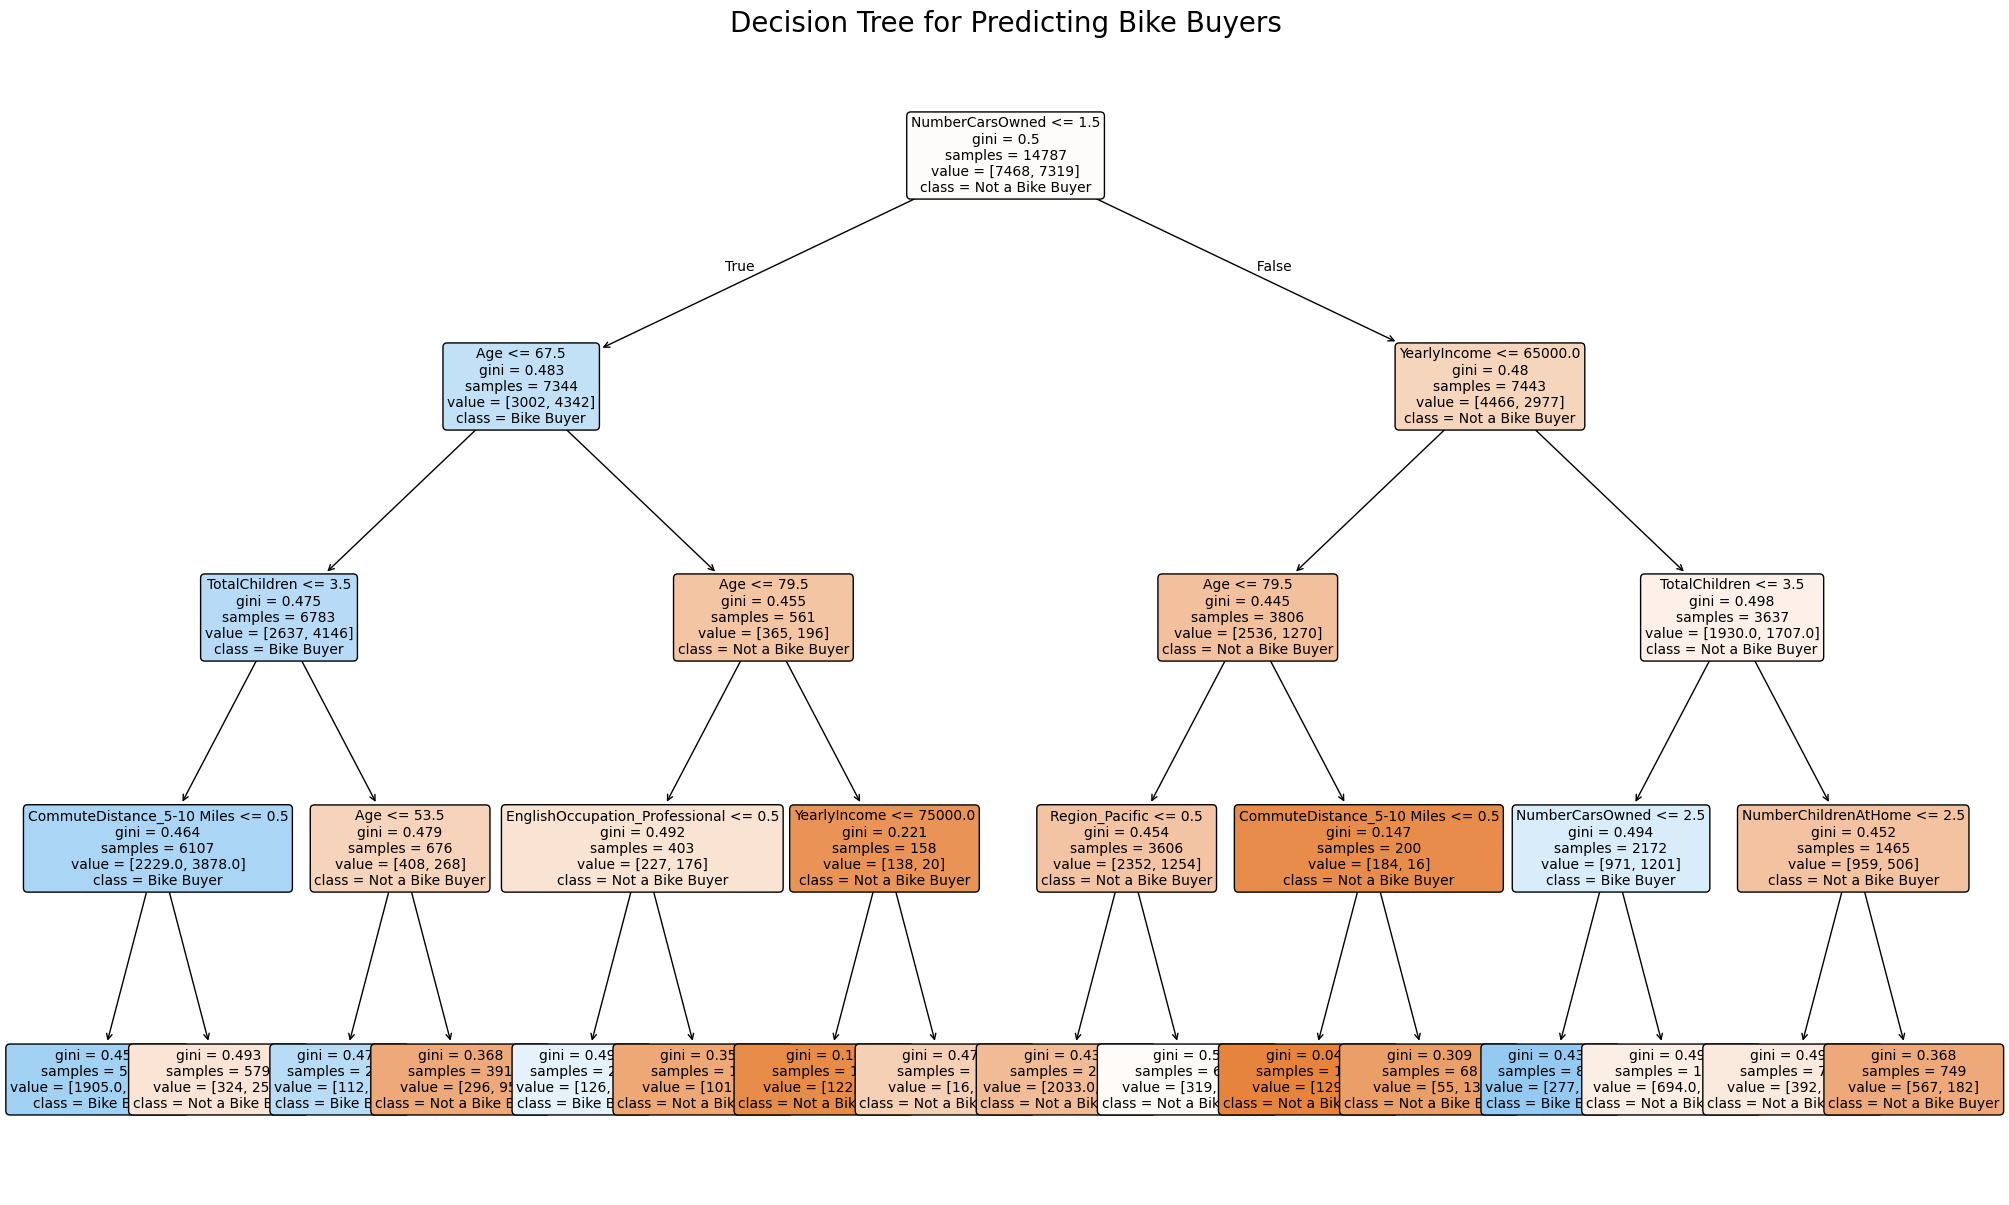

In [14]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Get the feature names and class names for the plot
feature_names = X.columns.tolist()
class_names = ['Not a Bike Buyer', 'Bike Buyer'] # Corresponds to 0 and 1

# Create the plot
plt.figure(figsize=(25, 15)) # Make the figure nice and big
plot_tree(model, 
          filled=True, 
          feature_names=feature_names, 
          class_names=class_names, 
          rounded=True, 
          fontsize=10)

plt.title("Decision Tree for Predicting Bike Buyers", fontsize=20)
plt.show()